In [3]:
#  Import Libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# sns.set(style="whitegrid")
# plt.rcParams['figure.figsize'] = (16,6)

#  Load Datasets
# -----------------------------
students = pd.read_csv('students.csv')
courses = pd.read_csv('courses.csv')
enrollments = pd.read_csv('enrollments.csv')

# Merge enrollment with students and courses
data = enrollments.merge(students, on='Student_ID', how='left')
data = data.merge(courses, on='Course_ID', how='left')

print("Merged Dataset Shape:", data.shape)
data.info()


Merged Dataset Shape: (15991, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15991 entries, 0 to 15990
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Student_ID    15991 non-null  object 
 1   Course_ID     15991 non-null  object 
 2   Grade         15991 non-null  object 
 3   Name          15991 non-null  object 
 4   Gender        15991 non-null  object 
 5   Age           15991 non-null  int64  
 6   Department_x  15991 non-null  object 
 7   Year          15991 non-null  int64  
 8   Attendance    15991 non-null  float64
 9   Study_Hours   15991 non-null  float64
 10  Current_GPA   15991 non-null  float64
 11  Course_Name   15991 non-null  object 
 12  Teacher_Name  15991 non-null  object 
 13  Department_y  15991 non-null  object 
 14  Credits       15991 non-null  int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 1.8+ MB


In [ ]:
#data.info()

NameError: name 'data' is not defined

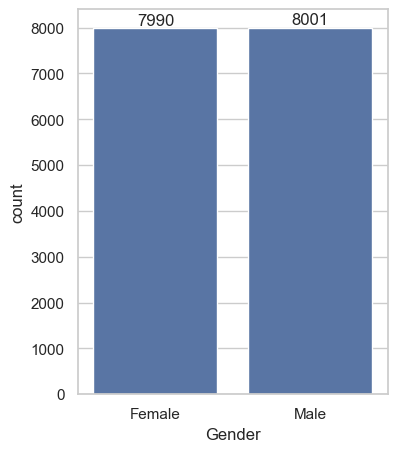

In [5]:
ax = sns.countplot(x='Gender',data = data)
plt.rcParams['figure.figsize'] = (2,5)
for bars in ax.containers:
    ax.bar_label(bars)

C:\Users\pallab\AppData\Local\Temp\ipykernel_14416\466033439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Current_GPA', data=dept_gpa, palette='viridis')


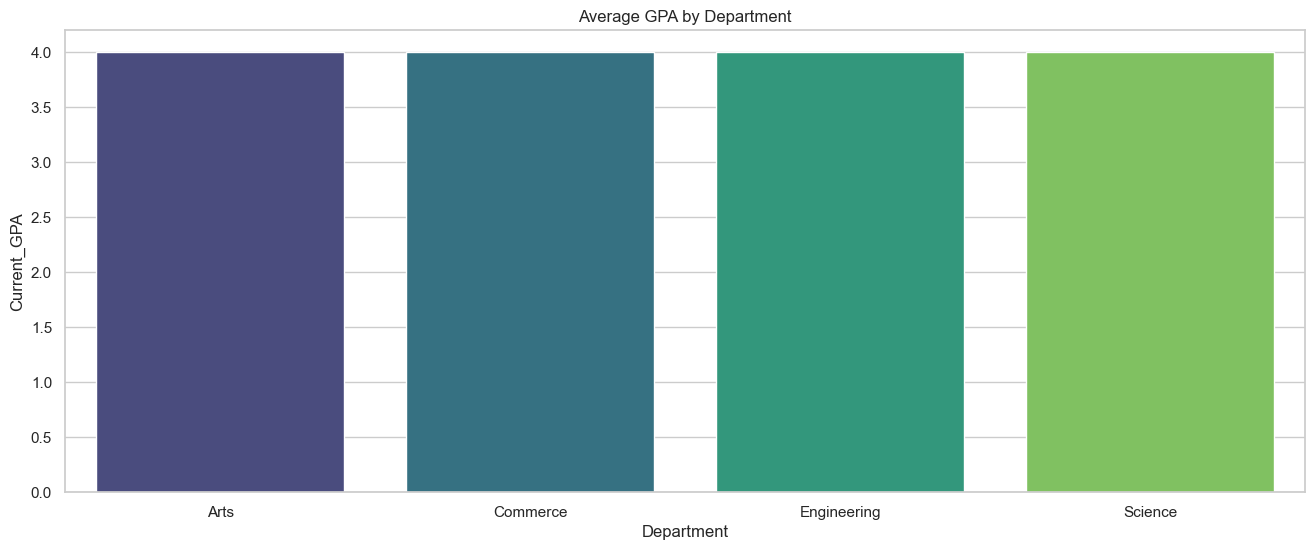

In [ ]:
# Department-wise Average GPA
dept_gpa = students.groupby('Department')['Current_GPA'].mean().reset_index()
sns.barplot(x='Department', y='Current_GPA', data=dept_gpa, palette='viridis')
plt.title("Average GPA by Department")
plt.show()


C:\Users\pallab\AppData\Local\Temp\ipykernel_14416\3391453685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Current_GPA', y='Teacher_Name', data=teacher_gpa, palette='magma')


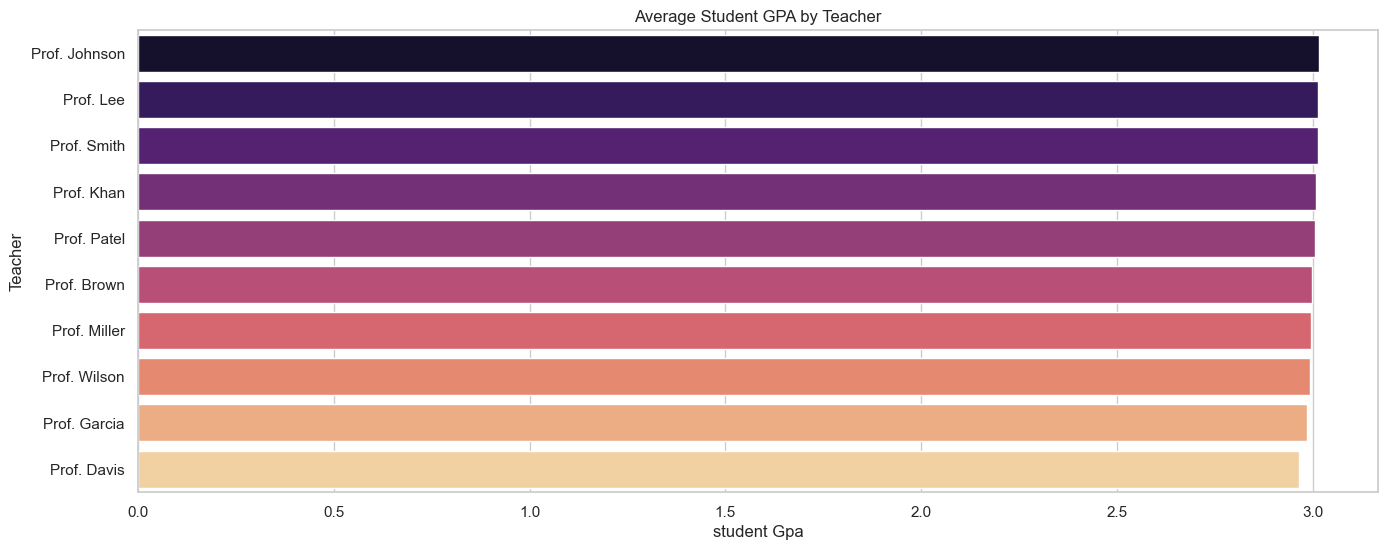

In [82]:
# Teacher-wise Average Student GPA
teacher_gpa = data.groupby('Teacher_Name')['Current_GPA'].mean().reset_index().sort_values(by='Current_GPA', ascending=False)
sns.barplot(x='Current_GPA', y='Teacher_Name', data=teacher_gpa, palette='magma')
plt.title("Average Student GPA by Teacher")
plt.xlabel("student Gpa")
plt.ylabel("Teacher")
plt.show()

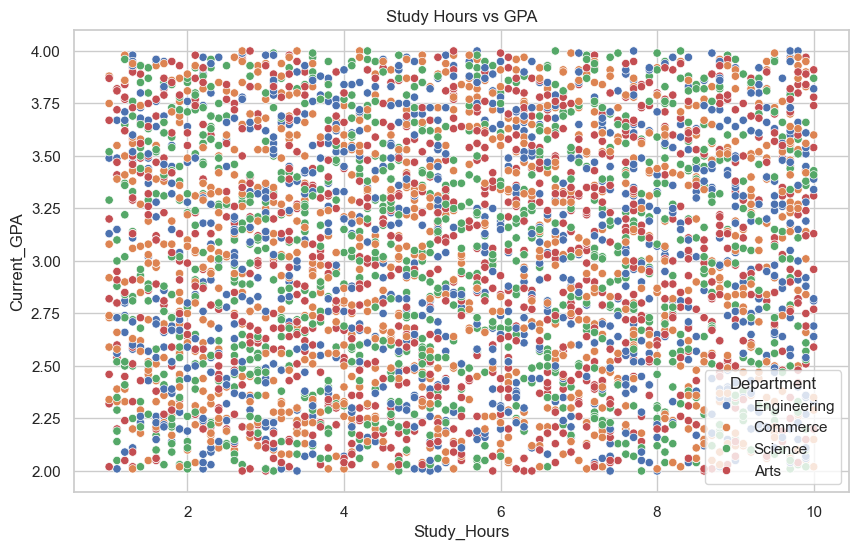

Correlation between Study Hours and GPA: 0.01987250910650805


In [68]:
# Study Hours vs GPA
sns.scatterplot(x='Study_Hours', y='Current_GPA', data=students, hue='Department')
plt.title("Study Hours vs GPA")
plt.show()

print("Correlation between Study Hours and GPA:", students['Study_Hours'].corr(students['Current_GPA']))


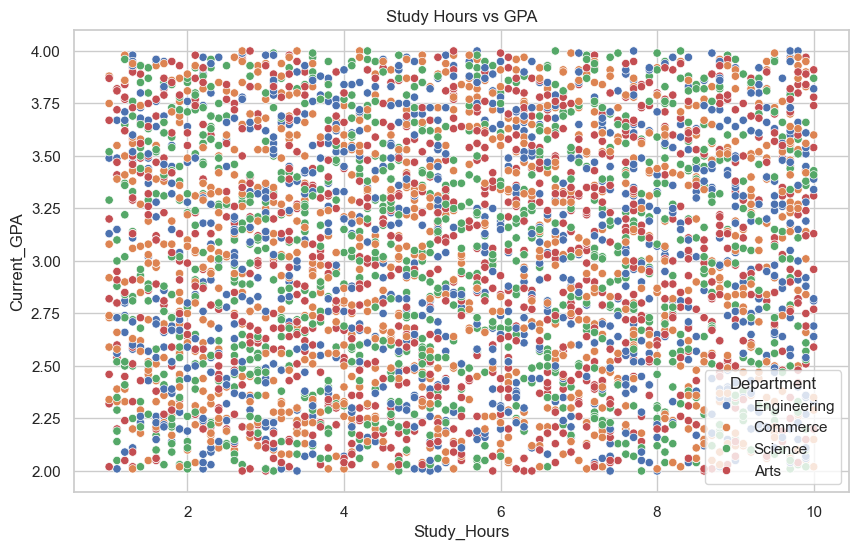

Correlation between Study Hours and GPA: 0.01987250910650805


In [53]:
# Study Hours vs GPA

sns.scatterplot(x='Study_Hours', y='Current_GPA', data=students, hue='Department')
plt.title("Study Hours vs GPA")
plt.show()

print("Correlation between Study Hours and GPA:", students['Study_Hours'].corr(students['Current_GPA']))

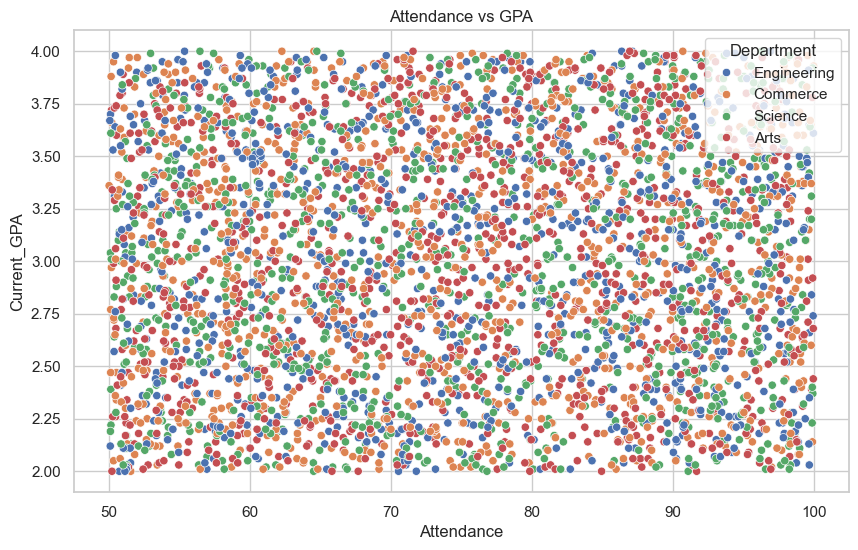

Correlation between Attendance and GPA: 0.029899370478063368


In [54]:
# Attendance vs GPA
sns.scatterplot(x='Attendance', y='Current_GPA', data=students, hue='Department')
plt.title("Attendance vs GPA")
plt.show()

print("Correlation between Attendance and GPA:", students['Attendance'].corr(students['Current_GPA']))

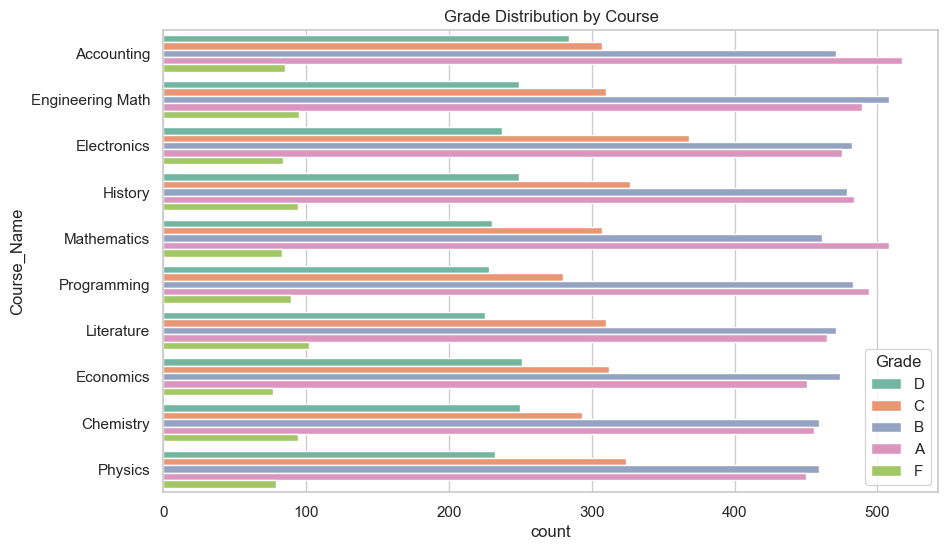

In [ ]:
# Course-wise Grade Distribution

sns.countplot(y='Course_Name', hue='Grade', data=data, order=data['Course_Name'].value_counts().index, palette='Set2')
plt.title("Grade Distribution by Course")
plt.show()